# Data Validation
Data validation for azimuthal radial profiles

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from astropy import units as u

from scipy.interpolate import RectBivariateSpline
import sys
np.set_printoptions(threshold=sys.maxsize)
import os

## Making fake star

In [2]:
blanky = np.ones([100,100]) # setting background value as 1
line_outward = np.arange(50,0,-1) # making star gradient
info = {'position': [49,49]} # setting star center

In [3]:
# for work computer

In [4]:
pwd

'/Users/iman/Documents/cuny_ms/csm_pipeline/data_validation'

In [5]:
cd /Users/ibehbehani/csm_pipeline

[Errno 2] No such file or directory: '/Users/ibehbehani/csm_pipeline'
/Users/iman/Documents/cuny_ms/csm_pipeline/data_validation


In [6]:
# for home computer

In [7]:
cd /Users/iman/Documents/cuny_ms/csm_pipeline/

/Users/iman/Documents/cuny_ms/csm_pipeline


In [8]:
from radial import radius2d
r_blanky = radius2d(blanky, info)*u.arcsec

In [9]:
starry = np.ones([blanky.shape[0], blanky.shape[1]])

for i in range(blanky.shape[0]):
    for j in range(blanky.shape[1]):
        r_i = int(np.round(r_blanky[i,j].value))

        if r_i>20:
            starry[i,j] = 1

        else:
            starry[i,j] = line_outward[r_i]

starry = starry.copy()*u.Jy/u.arcsec**2 # make Jy/arc2 so we can use it
starry

<Quantity [[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.],
           [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
             1.,  1.,  1.,  1.,

## Add distinguishable regional variation

In [10]:
# starry[60,60] = 100*u.Jy/u.arcsec**2
# starry[60,40] = 0*u.Jy/u.arcsec**2
# starry[40,60] = 75*u.Jy/u.arcsec**2
# starry[40,40] = 25*u.Jy/u.arcsec**2

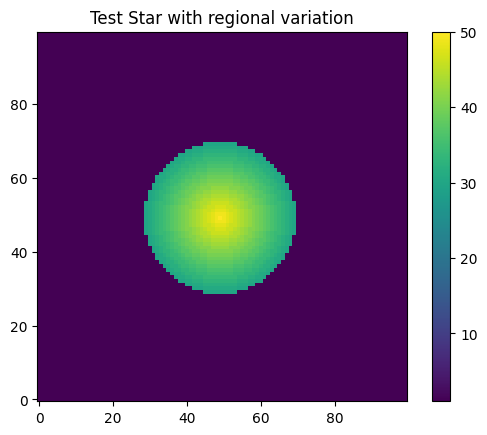

In [11]:
plt.imshow(starry.value.transpose(),origin='lower')
plt.title("Test Star with regional variation")
# plt.text(60,60,"150")
# plt.text(40,60, "100")
# plt.text(40,40, "25")
# plt.text(60,40, "0")
plt.colorbar()

actually starts facing due south and goes counter clockwise

In [12]:
np.where(starry==np.nanmax(starry))
cx=49
cy=49

In [13]:
n_lines = 401
n_pts = 400

psis = np.linspace(0,2*np.pi, n_lines,endpoint=True) #linspace 0 to 2pi radians
rs = np.linspace(0,cx+1,n_pts) # linspace 0 to 200 pixels

In [14]:
x_vals = np.zeros((n_lines, n_pts))

In [15]:
def get_coords(cx,cy, n_lines = n_lines, n_pts = n_pts,psis = np.linspace(0,2*np.pi, n_lines, endpoint=True),
          rs = np.linspace(0,cx,n_pts)):
    '''
    returns all x and y values for polar grid
    '''

    x_vals = np.zeros((n_lines, n_pts))
    y_vals = np.zeros((n_lines, n_pts))

    rys_xy = np.full((n_lines,n_pts),tuple)

    #pick coordinates for interpolation
    for i, psi in enumerate(psis):

        # polar to cartesian
        x_r = cx + rs * np.cos(psi) 
        y_r = cy + rs * np.sin(psi)

        x_vals[i]=x_r
        y_vals[i]=y_r

        for j in range(n_pts):
            rys_xy[i,j]=(x_r[j],y_r[j])


    return x_vals,y_vals,rys_xy
    # return rys,rys_xy

In [16]:
x = np.linspace(0,blanky[0,:].shape[0]-1,blanky[0,:].shape[0])
y = np.linspace(0,blanky[:,0].shape[0]-1,blanky[:,0].shape[0])

X,Y = np.meshgrid(x,y)
new_star_vals = RectBivariateSpline(x,y,starry.T) # making function to interpolate starry array

In [17]:
x_grid, y_grid,rys_xy = get_coords(cx,cy)

In [18]:
interp_star = new_star_vals(x_grid,y_grid,grid=False)

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/1552640123.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[1].pcolormesh(x_grid, y_grid, interp_star)


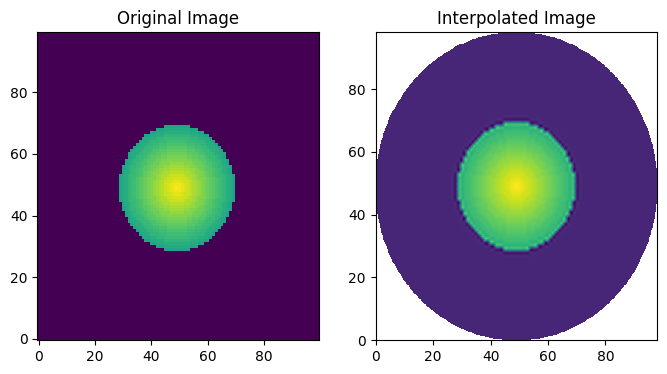

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(8,4))
ax[0].pcolormesh(X, Y, starry.value)
ax[0].set_title("Original Image")
# X2, Y2 = np.meshgrid(x, y)
ax[1].pcolormesh(x_grid, y_grid, interp_star)
ax[1].set_title("Interpolated Image")

plt.show()

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/3220476636.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_grid,y_grid,interp_star)


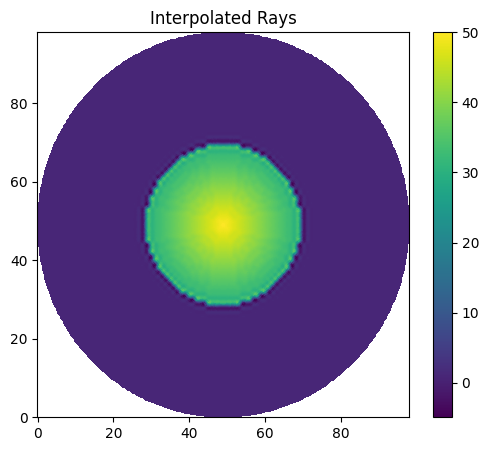

In [20]:
plt.figure(figsize=(6,5))
plt.pcolormesh(x_grid,y_grid,interp_star)
# plt.xlim(0,100)
# plt.ylim(0,100)
#plt.gca().invert_yaxis()

plt.title("Interpolated Rays")
plt.colorbar()

Trying with random array

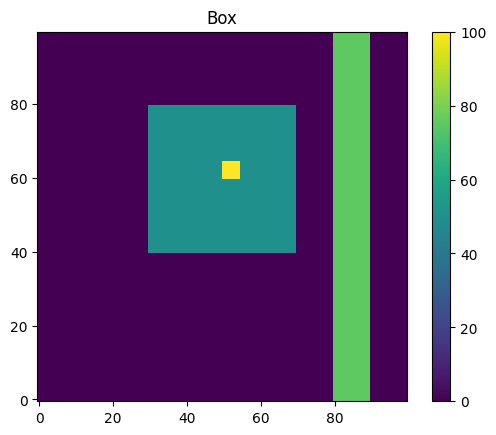

In [21]:
import numpy as np

# Image dimensions
width = 100
height = 100

# Create a NumPy array to represent the image
image = np.zeros((100, 100))

# Set colors for the eye

# Draw the eye
image[40:80, 30:70] = 50

# Draw the pupil
image[60:65, 50:55] = 100

image[0:100, 80:90] = 75


# Save the image
plt.imshow(image,origin = 'lower')
plt.title('Box')
plt.colorbar()

In [22]:
x=y=np.linspace(0,99,100)
new_image_vals = RectBivariateSpline(x,y,image.T)

In [23]:
x_grid, y_grid,rys_xy = get_coords(cx,cy)

In [24]:
interp_box = new_image_vals(x_grid,y_grid,grid=False)

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/1487586589.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[1].pcolormesh(x_grid, y_grid, interp_box)


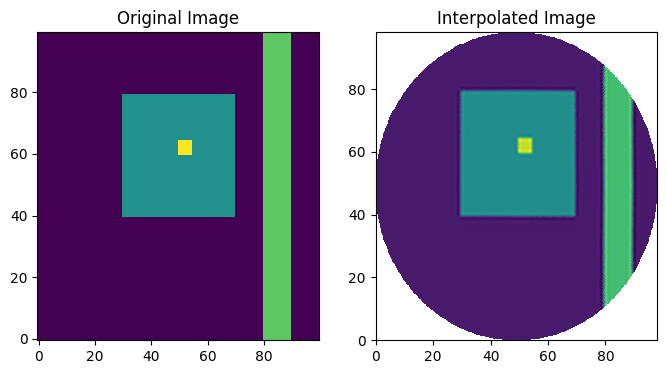

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(8,4))
ax[0].pcolormesh(X, Y, image)
ax[0].set_title("Original Image")
# ax[0].set_ylim(0, 100)

X2, Y2 = np.meshgrid(x, y)
ax[1].pcolormesh(x_grid, y_grid, interp_box)
ax[1].set_title("Interpolated Image")

# ax[1].set_ylim(0, 100)

plt.show()

In [26]:
interp_box_temp = np.zeros((len(interp_box),len(interp_box[0])))
interp_box_temp.shape

(401, 400)

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/3165116534.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(x_grid, y_grid, interp_box)


Text(0.5, 1.0, 'Interpolated Image')

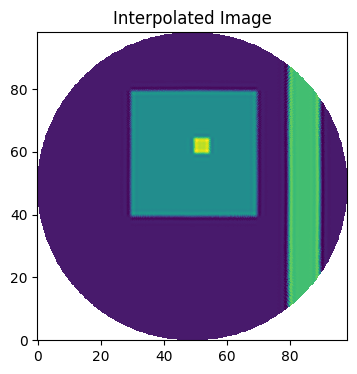

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
ax.pcolormesh(x_grid, y_grid, interp_box)
ax.set_title("Interpolated Image")

In [28]:
# making rays for reference
for i in range(len(interp_box)):
    for j in range(len(interp_box[0])):
        #print(i)
        if i%10==0:
            interp_box_temp[i,j] = 100
            #print(i,j)
        else:
            interp_box_temp[i,j] = interp_box[i,j]


/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/2017097099.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x_grid,y_grid,interp_box_temp)


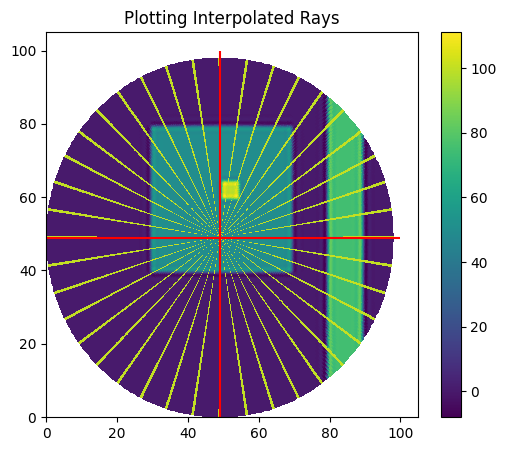

In [29]:
plt.figure(figsize=(6,5))
plt.pcolormesh(x_grid,y_grid,interp_box_temp)
# plt.xlim(0,100)
# plt.ylim(0,100)
#plt.gca().invert_yaxis()
plt.vlines(49,0,100,colors='red')
plt.hlines(49,0,100,colors='red')


plt.title("Plotting Interpolated Rays")
plt.colorbar()

# IAT Data Val

In [80]:
def abel_data_val(data, center, x_grid, y_grid, min, max):
    xaxis = x_grid-(center)
    yaxis = y_grid-(center)

    radius_2d = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
    #fill pc array of radii
    for i in range(x_grid.shape[0]):
        for j in range(x_grid.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d[i,j] = np.sqrt(c)

    csm_abel = []
    row = np.zeros(len(data[i,:]))

    for i in range(len(data[:,0])):
        # print('i',i)
        row = np.zeros(len(data[i,:]))

        row = do_abel(data[i,:],(radius_2d[i,:]),0)
        #print(df_ds_temp.shape)

        csm_abel.append(row)


    abel_plot(csm_abel, data,xaxis,yaxis, min, max)

    return xaxis, yaxis, csm_abel 

    

In [81]:
def abel_plot(csm_abel,data,xaxis,yaxis,min,max):
    #plot it up!
    fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))
    fig.suptitle("IAT Result with Rays")

    im0 = ax[0].pcolormesh(xaxis, yaxis, data)

    ax[0].set_xlabel("Radius (arc)")
    ax[0].set_ylabel("Radius (arc)")

    ax[0].set_title("Surface Density Image")
    fig.colorbar(im0,label = "Density in g/cm2")

    ### abel image
    c=1
    im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel, vmin =min, vmax=max)
    #im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)

    ax[1].set_xlabel("Radius (arc)")
    ax[1].set_ylabel("Radius (arc)")


    ax[1].set_title("IA Transformed Image")
    fig.colorbar(im1,label = "Density in g/cm3")

In [82]:
from abel import do_abel

In [83]:
def do_abel_2(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''

    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = 0#med/1000 # turn negative values into background 0 or median
    dF_ds = np.gradient(F,s) 

    
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))
    
    for i in range(len(s)-1):
        
        r = (s[i]+s[i+1])/2 # set r values (3D radial coords) to s (on sky radius) bin centers
        r_arr[i] = r                    # curtails potential div by zero issues
        
        # integrate from r to highest radial value
        integ = np.trapz(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
        
        # multiply integral result by -1/pi coefficient
        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value

    return f_r, dF_ds

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/299795889.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im0 = ax[0].pcolormesh(xaxis, yaxis, data)
/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/299795889.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel, vmin =min, vmax=max)


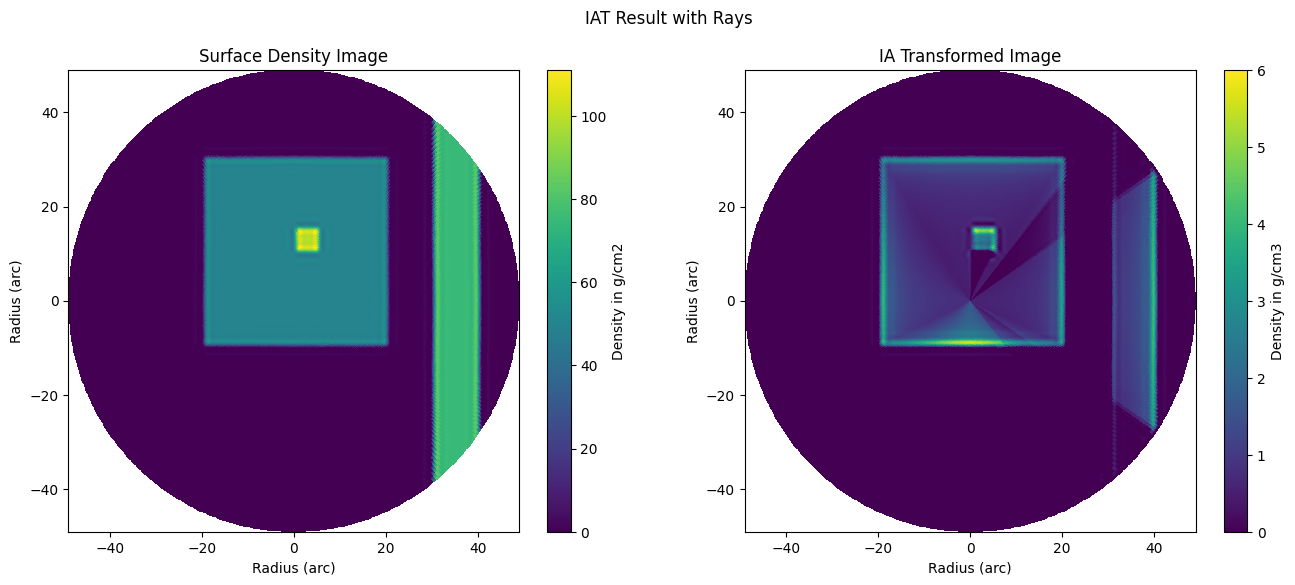

In [84]:
xaxis_box, yaxis_box, abel_box = abel_data_val(interp_box, 49, x_grid=x_grid, y_grid=y_grid, min = 0, max= 6)

In [85]:
np.nanmax(abel_box)

5.630949404360512

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/299795889.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im0 = ax[0].pcolormesh(xaxis, yaxis, data)
/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_39523/299795889.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel, vmin =min, vmax=max)


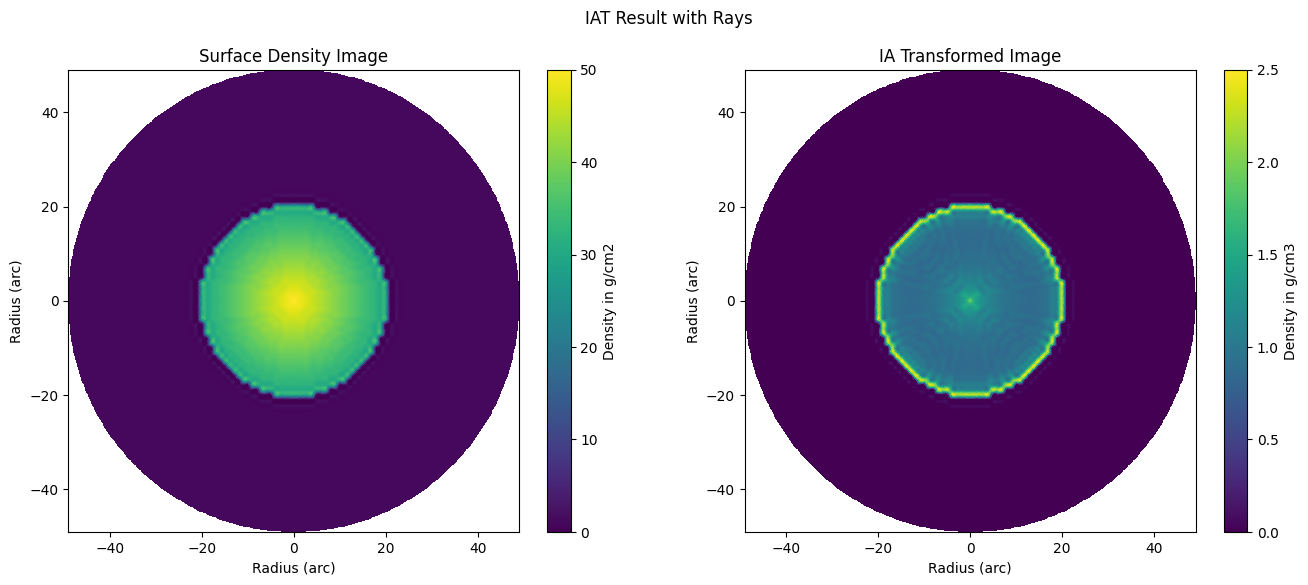

In [86]:
xaxis_star, yaxis_star, abel_star = abel_data_val(interp_star, 49, x_grid=x_grid, y_grid=y_grid, min = 0, max=2.5)

In [79]:
np.max(abel_star)

2.4555659839927295

In [90]:
single_ray_star = do_abel(interp_star[0,49:],xaxis_star[0,49:],1)

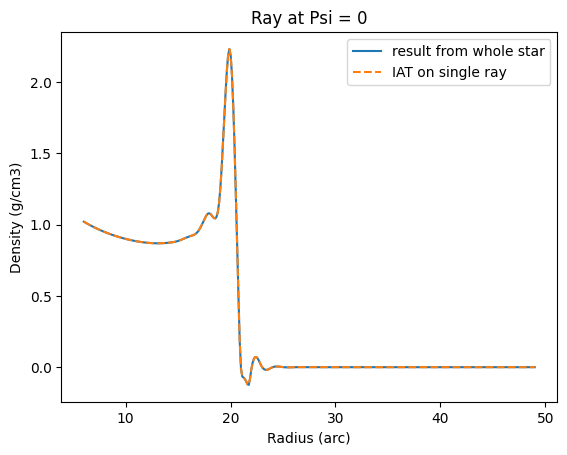

In [97]:
abel_star = np.array(abel_star)
plt.plot(xaxis_star[0,49:], abel_star[0,49:],label = 'result from whole star')
plt.plot(xaxis_star[0,49:],single_ray_star, label = 'IAT on single ray', linestyle = '--')
plt.title("Ray at Psi = 0")
plt.xlabel("Radius (arc)")
plt.ylabel("Density (g/cm3)")
plt.legend()